
# EDA: Supercritical Water Source Summary — Luo (2020) (`supercritical_water_source_summary_luo2020.csv`)

A small source-summary table where the single packed column
`P_MPa_G_kg_m2s_q_kW_m2_range` encodes pressure, mass-flux and heat-flux
ranges per source as `"P / G / q"` (each of `P`, `G`, `q` itself possibly a
single value, a comma list, or a dash range). `D_mm` is parsed the same way.

## 1. Load Data


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 60)
plt.rcParams["figure.dpi"] = 100

DATA_DIR = Path("../../data/raw/external")
OUT_DIR = Path("../../results/eda/supercritical_water_source_summary_luo2020")
FIG_DIR = OUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_DIR / "supercritical_water_source_summary_luo2020.csv")
df

,Source,P_MPa_G_kg_m2s_q_kW_m2_range,D_mm,N_points
0,Shiralkar and Griffith,"22.7,23.4/461-610/252.4-2328.6","10,16",7
1,Vikhrev et al.,"26.5/495,1400/507-930",20.4,3
2,Yamagata et al.,24.6/1260/233-698,"7.5,10",4
3,Mokry et al.,24/201-1500/129-1500,10,18
4,Wang et al.,23-26/450-1200/200-1200,10,17
5,Zhu et al.,"23-30/600,1200/200,300",26,6
6,Pan et al.,22.5-30/1009-1626/216-822,17,10
7,Alekseev et al.,24.5/650/560,10.4,1
8,Griem,"22,25/500-2500/300-600",14,6
9,Li et al. (a),23-26/459.8-1497.5/192-1326.5,7.6,23


## 2. Parse Packed Ranges

In [2]:
import re

def parse_minmax(token):
    # Parse a range-ish string token into (min, max) floats.
    # Handles: '20, 60' (list), '2.09-4.44' (dash range),
    # '-0.5 to -0.25' (worded range, needed for negative bounds), '1000' (single value).
    if pd.isna(token):
        return np.nan, np.nan
    s = str(token).strip()
    if s == "":
        return np.nan, np.nan
    if " to " in s:
        a, b = s.split(" to ")
        a, b = float(a), float(b)
        return min(a, b), max(a, b)
    if "," in s:
        vals = [float(t.strip()) for t in s.split(",")]
        return min(vals), max(vals)
    m = re.match(r"^(-?\d+\.?\d*)-(-?\d+\.?\d*)$", s)
    if m:
        a, b = float(m.group(1)), float(m.group(2))
        return min(a, b), max(a, b)
    v = float(s)
    return v, v

In [3]:
def split_pgq(s):
    parts = str(s).split("/")
    assert len(parts) == 3, f"unexpected format: {s}"
    return parts  # P, G, q substrings

pgq = df["P_MPa_G_kg_m2s_q_kW_m2_range"].map(split_pgq)
p_str = pgq.map(lambda t: t[0])
g_str = pgq.map(lambda t: t[1])
q_str = pgq.map(lambda t: t[2])

parsed = df[["Source"]].copy()
for name, s in [("P_MPa", p_str), ("G_kg_m2s", g_str), ("q_kW_m2", q_str), ("D_mm", df["D_mm"])]:
    mins, maxs = zip(*s.map(parse_minmax))
    parsed[f"{name}_min"] = mins
    parsed[f"{name}_max"] = maxs
parsed["N_points"] = df["N_points"]
parsed.to_csv(OUT_DIR / "parsed_ranges.csv", index=False)
parsed

,Source,P_MPa_min,P_MPa_max,G_kg_m2s_min,G_kg_m2s_max,q_kW_m2_min,q_kW_m2_max,D_mm_min,D_mm_max,N_points
0,Shiralkar and Griffith,22.7,23.4,461.0,610.0,252.4,2328.6,10.00,16.00,7
1,Vikhrev et al.,26.5,26.5,495.0,1400.0,507.0,930.0,20.40,20.40,3
2,Yamagata et al.,24.6,24.6,1260.0,1260.0,233.0,698.0,7.50,10.00,4
3,Mokry et al.,24.0,24.0,201.0,1500.0,129.0,1500.0,10.00,10.00,18
4,Wang et al.,23.0,26.0,450.0,1200.0,200.0,1200.0,10.00,10.00,17
5,Zhu et al.,23.0,30.0,600.0,1200.0,200.0,300.0,26.00,26.00,6
6,Pan et al.,22.5,30.0,1009.0,1626.0,216.0,822.0,17.00,17.00,10
7,Alekseev et al.,24.5,24.5,650.0,650.0,560.0,560.0,10.40,10.40,1
8,Griem,22.0,25.0,500.0,2500.0,300.0,600.0,14.00,14.00,6
9,Li et al. (a),23.0,26.0,459.8,1497.5,192.0,1326.5,7.60,7.60,23


## 3. Range Coverage by Source

In [4]:
def plot_range_bars(ax, labels, mins, maxs, title, xlabel=""):
    y = np.arange(len(labels))
    ax.hlines(y, mins, maxs, color="#4C72B0", linewidth=6)
    ax.plot(mins, y, "|", color="#2f4b7c", markersize=14, markeredgewidth=2)
    ax.plot(maxs, y, "|", color="#2f4b7c", markersize=14, markeredgewidth=2)
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(xlabel)
    ax.invert_yaxis()

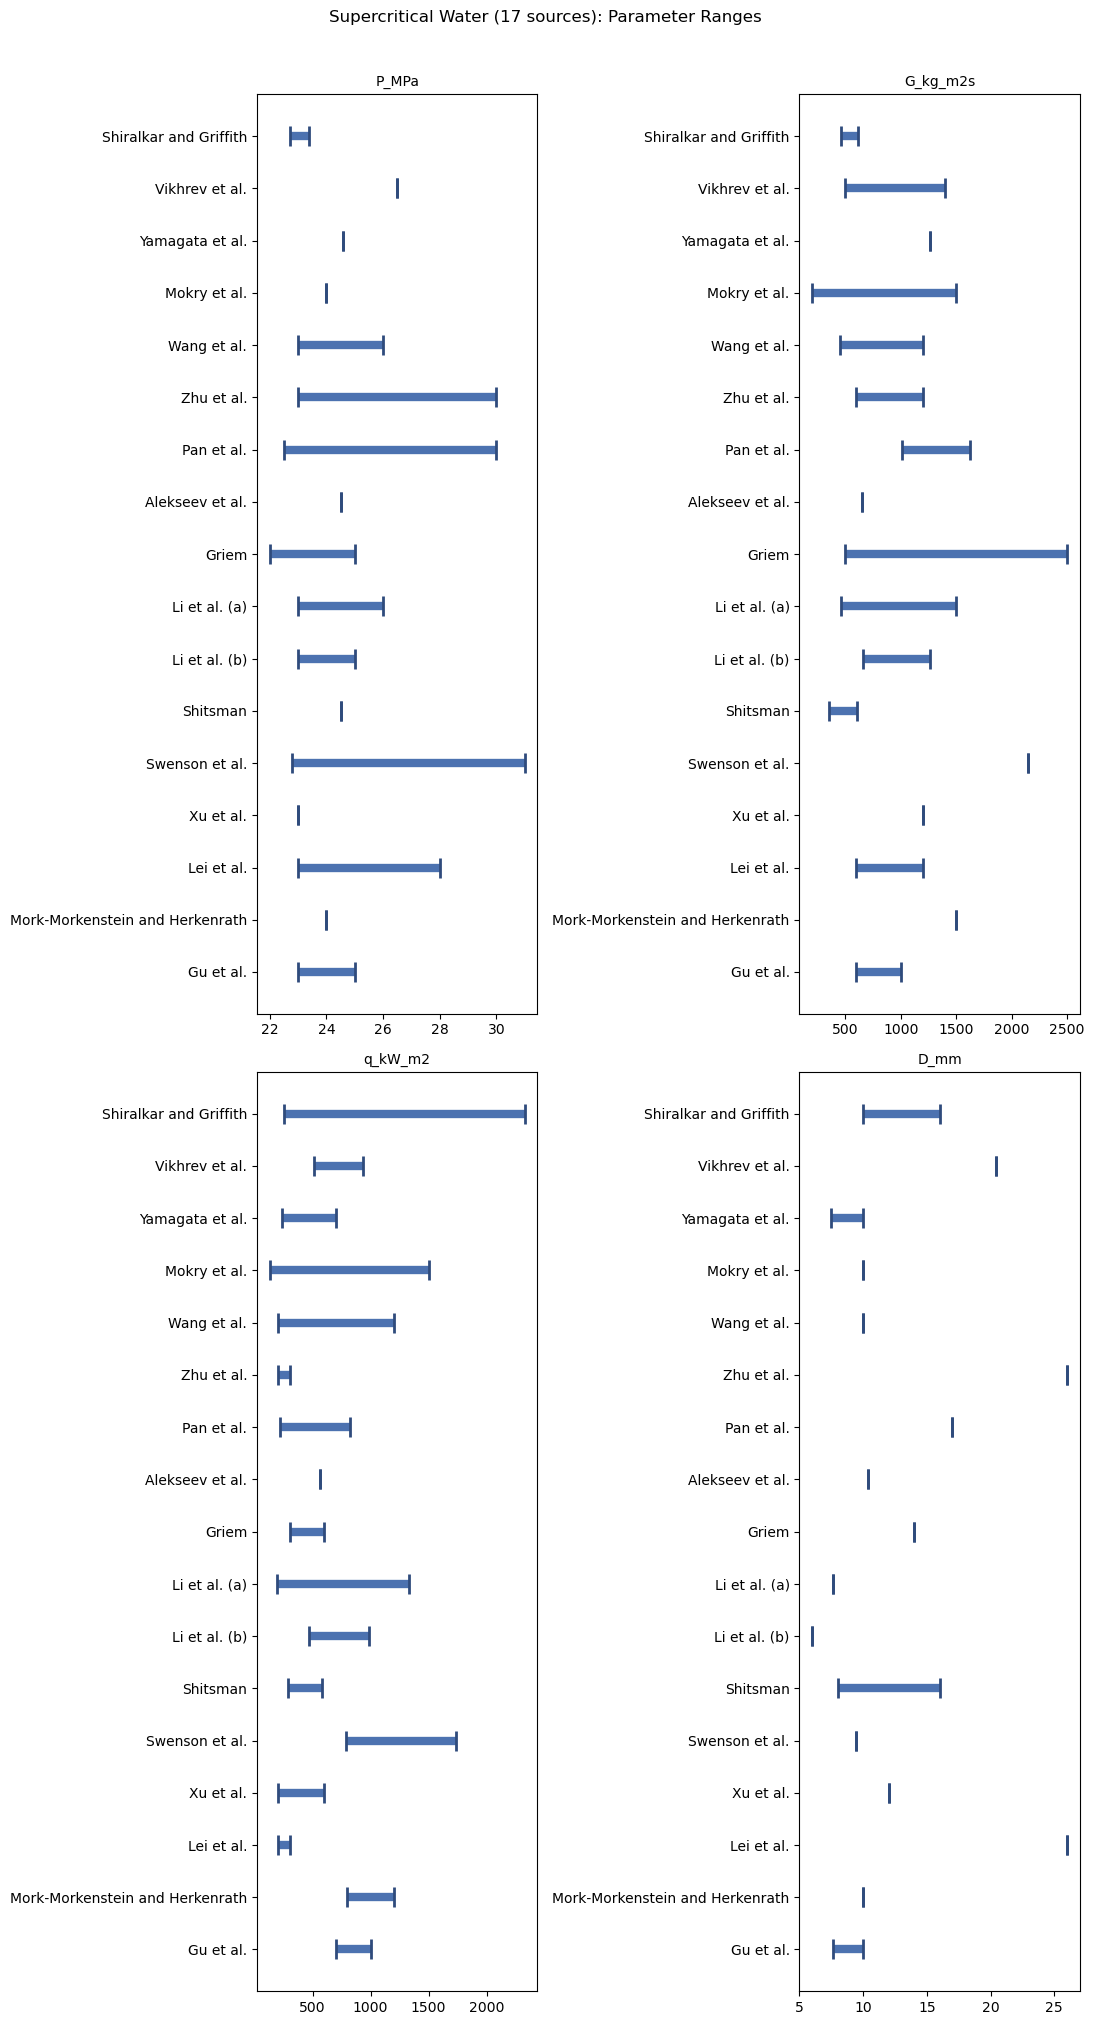

In [5]:
range_vars = ["P_MPa", "G_kg_m2s", "q_kW_m2", "D_mm"]
fig, axes = plt.subplots(2, 2, figsize=(11, 1.0 * len(df) + 3))
axes = axes.reshape(-1)
for ax, var in zip(axes, range_vars):
    plot_range_bars(ax, parsed["Source"], parsed[f"{var}_min"], parsed[f"{var}_max"], var)
fig.suptitle(f"Supercritical Water ({{n}} sources): Parameter Ranges".format(n=len(df)), y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / "range_coverage_by_source.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Sample Counts by Source

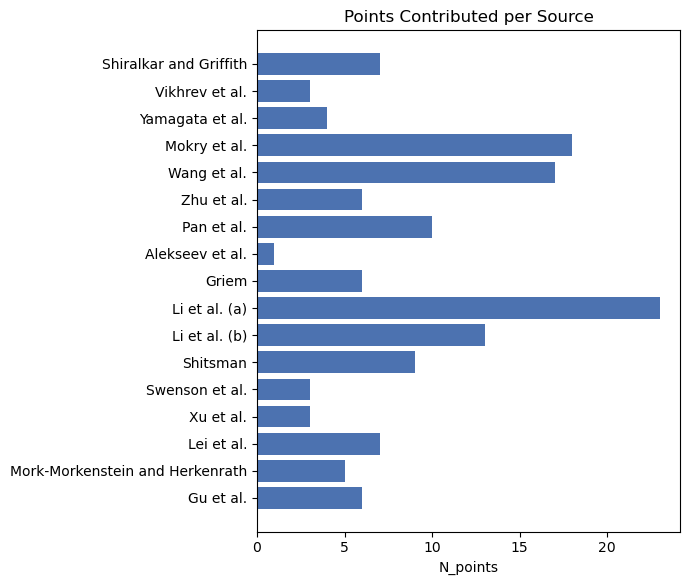

In [6]:
fig, ax = plt.subplots(figsize=(7, max(3, 0.35 * len(df))))
ax.barh(df["Source"], df["N_points"], color="#4C72B0")
ax.invert_yaxis()
ax.set_xlabel("N_points")
ax.set_title(f"Points Contributed per Source")
fig.tight_layout()
fig.savefig(FIG_DIR / "n_points_by_source.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Takeaways

- Pressure ranges cluster around the Water critical/supercritical
  region for this fluid; check `parsed_ranges.csv` for the exact per-source
  span rather than eyeballing the packed source strings.
- A few sources report only a single `(P, G, q)` operating point
  (`N_points` small, `min == max`) rather than a swept range — these plot as
  a single tick rather than a bar in the range-coverage figure.